# Diff Drive DDPG Run

Train and evaluate the continuous differential-drive DDPG agent. Outputs are saved inside `Continuous_Diff_Drive/videos`, `Continuous_Diff_Drive/images`, and `Continuous_Diff_Drive/models`.

In [1]:
from pathlib import Path
import sys

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name != "Continuous_Diff_Drive":
        BASE_DIR = BASE_DIR / "Continuous_Diff_Drive"

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from diff_drive_agent import DiffDriveAgent
from diff_drive_env import DiffDriveEnv

BASE_DIR

PosixPath('/Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive')

## Configuration

In [2]:
# A room with a few axis-aligned rectangular obstacles.
# Each obstacle is (x, y, width, height) in metres, origin at bottom-left.
OBSTACLES = [
    (2.0, 4.0, 1.5, 0.3),
    (5.0, 2.0, 0.3, 3.0),
    (7.0, 6.0, 1.5, 0.3),
]

ENV_KWARGS = dict(
    room_size       = (10.0, 10.0),
    obstacles       = None,
    random_obst     = True,
    robot_start     = (1.0, 1.0),
    goal_pos        = (8.5, 8.5),
    max_step        = 1000,
    n_lidar_rays    = 16,
    lidar_max_range = 5.0,
    robot_radius    = 0.3,
    dt              = 0.1,
    render_mode     = "rgb_array",
)

NUM_EPISODES  = 2_000
RECORD_EVERY  = 500
LOG_EVERY     = 100

ACTOR_LR      = 1e-4
CRITIC_LR     = 1e-3
DISCOUNT      = 0.95
TAU           = 0.005
NOISE_STD     = 0.2
NOISE_CLIP    = 0.5
BATCH_SIZE    = 256
BUFFER_SIZE   = 100_000
HIDDEN_DIM    = 128
WARMUP_STEPS  = 1_000
DEVICE        = "cpu"

RUN_TRAINING = True
LOAD_CHECKPOINT_FOR_EVAL = False

## Output Paths

In [3]:
VIDEO_DIR = BASE_DIR / "videos"
TRAINING_VIDEO_DIR = VIDEO_DIR / "training"
EVALUATION_VIDEO_DIR = VIDEO_DIR / "evaluation"
IMAGE_DIR = BASE_DIR / "images"
MODEL_DIR = BASE_DIR / "models"
CHECKPOINT_PATH = MODEL_DIR / "ddpg_checkpoint.pt"
PLOT_PATH = IMAGE_DIR / "ddpg_diff_drive_training_curves.png"

TRAINING_NAME_PREFIX = "ddpg_diff_drive_training_random_obstacles_ou_noise"
EVALUATION_NAME_PREFIX = "ddpg_diff_drive_eval_random_obstacles_greedy"

for directory in (TRAINING_VIDEO_DIR, EVALUATION_VIDEO_DIR, IMAGE_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

VIDEO_DIR

PosixPath('/Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/videos')

## Environment and Agent

In [4]:
env = DiffDriveEnv(**ENV_KWARGS)

agent = DiffDriveAgent(
    env          = env,
    actor_lr     = ACTOR_LR,
    critic_lr    = CRITIC_LR,
    discount     = DISCOUNT,
    tau          = TAU,
    noise_std    = NOISE_STD,
    noise_clip   = NOISE_CLIP,
    batch_size   = BATCH_SIZE,
    buffer_size  = BUFFER_SIZE,
    hidden_dim   = HIDDEN_DIM,
    warmup_steps = WARMUP_STEPS,
    device       = DEVICE,
)

agent

## Training

In [5]:
if RUN_TRAINING:
    print("=" * 60)
    print("  DiffDrive - DDPG Training")
    print(f"  Episodes   : {NUM_EPISODES}")
    print(f"  Warmup     : {WARMUP_STEPS} steps")
    print(f"  Buffer     : {BUFFER_SIZE}")
    print(f"  Batch size : {BATCH_SIZE}")
    print(f"  Device     : {DEVICE}")
    print(f"  Videos     : {VIDEO_DIR}")
    print("=" * 60)

    agent.train_recorded(
        num_episodes   = NUM_EPISODES,
        video_folder   = TRAINING_VIDEO_DIR,
        record_every   = RECORD_EVERY,
        log_every      = LOG_EVERY,
        add_noise      = True,
        name_prefix    = TRAINING_NAME_PREFIX,
        checkpoint_path = CHECKPOINT_PATH,
        plot_path      = PLOT_PATH,
    )
else:
    print("Training skipped.")

  DiffDrive - DDPG Training
  Episodes   : 2000
  Warmup     : 1000 steps
  Buffer     : 100000
  Batch size : 256
  Device     : cpu
  Videos     : /Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/videos


/Users/anthonymc/Desktop/NAML_project/venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/videos/training folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
Training:   5%|▌         | 100/2000 [01:09<20:04,  1.58it/s] 

  Episode   100 | avg reward (last 100): 125.46 | buffer:  13614 | steps: 13614


Training:  10%|█         | 200/2000 [02:05<16:55,  1.77it/s]

  Episode   200 | avg reward (last 100): 194.67 | buffer:  25111 | steps: 25111


...

Training:  95%|█████████▌| 1900/2000 [18:30<00:53,  1.85it/s]

  Episode  1900 | avg reward (last 100): 220.81 | buffer: 100000 | steps: 241837


Training: 100%|██████████| 2000/2000 [19:25<00:00,  1.72it/s]

  Episode  2000 | avg reward (last 100): 201.50 | buffer: 100000 | steps: 253936
Checkpoint saved to /Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/models/ddpg_checkpoint.pt


Plot saved to /Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/images/ddpg_diff_drive_training_curves.png


## Checkpoint Loading

In [6]:
if LOAD_CHECKPOINT_FOR_EVAL:
    import torch

    if not CHECKPOINT_PATH.exists():
        raise FileNotFoundError(f"No checkpoint found at {CHECKPOINT_PATH}")

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    agent.actor.load_state_dict(checkpoint["actor"])
    agent.critic.load_state_dict(checkpoint["critic"])
    agent.actor_target.load_state_dict(checkpoint["actor_target"])
    agent.critic_target.load_state_dict(checkpoint["critic_target"])
    print(f"Loaded checkpoint from {CHECKPOINT_PATH}")
else:
    print("Using the current in-memory agent for evaluation.")

Using the current in-memory agent for evaluation.


## Evaluation

In [7]:
agent.eval_recorded(
    video_folder = EVALUATION_VIDEO_DIR,
    name_prefix  = EVALUATION_NAME_PREFIX,
    n_episodes   = 3,
    add_noise    = False,
)

/Users/anthonymc/Desktop/NAML_project/venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/videos/evaluation folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


  Eval ep 1: reward = 224.4 | steps = 103 | goal reached: ✓
  Eval ep 2: reward = 225.0 | steps = 103 | goal reached: ✓
  Eval ep 3: reward = 224.8 | steps = 104 | goal reached: ✓


## Generated Artifacts

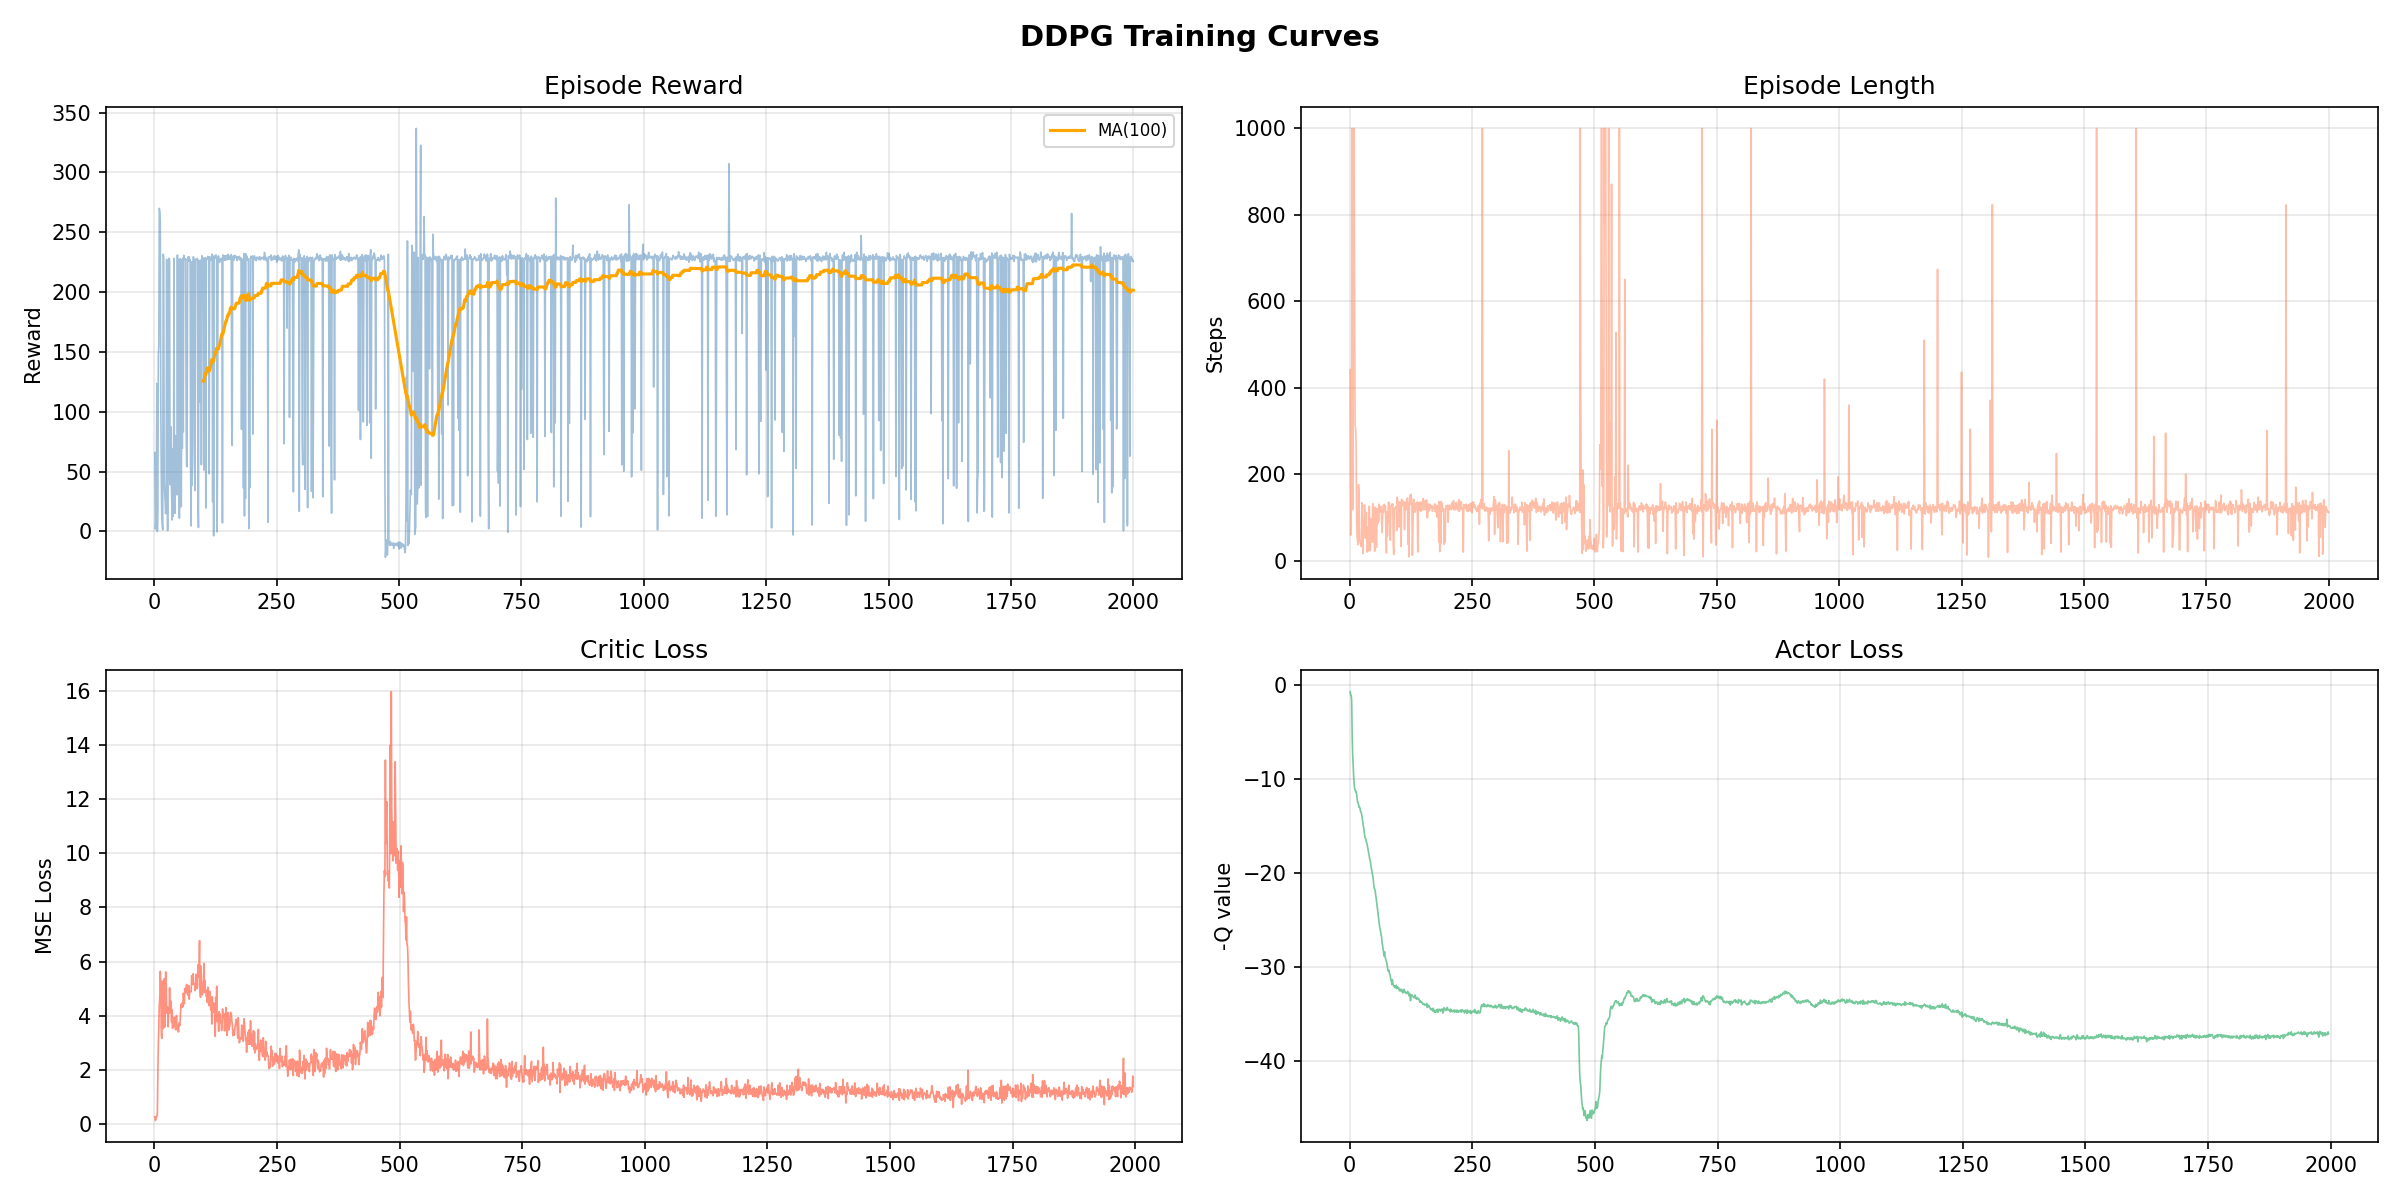

ddpg_diff_drive_training_random_obstacles_ou_noise-episode-0.mp4
ddpg_diff_drive_training_random_obstacles_ou_noise-episode-1000.mp4
ddpg_diff_drive_training_random_obstacles_ou_noise-episode-1500.mp4
ddpg_diff_drive_training_random_obstacles_ou_noise-episode-500.mp4
ddpg_diff_drive_eval_random_obstacles_greedy-episode-0.mp4


ddpg_diff_drive_eval_random_obstacles_greedy-episode-1.mp4


ddpg_diff_drive_eval_random_obstacles_greedy-episode-2.mp4


In [8]:
from IPython.display import Image, Video, display

if PLOT_PATH.exists():
    display(Image(filename=str(PLOT_PATH)))

for video_path in sorted(TRAINING_VIDEO_DIR.glob(f"{TRAINING_NAME_PREFIX}*.mp4")):
    print(video_path.name)

for video_path in sorted(EVALUATION_VIDEO_DIR.glob(f"{EVALUATION_NAME_PREFIX}*.mp4")):
    print(video_path.name)
    display(Video(filename=str(video_path), embed=True))